In [ ]:
!pip install numpy pandas matplotlib scikit-learn tensorflow

LSTM

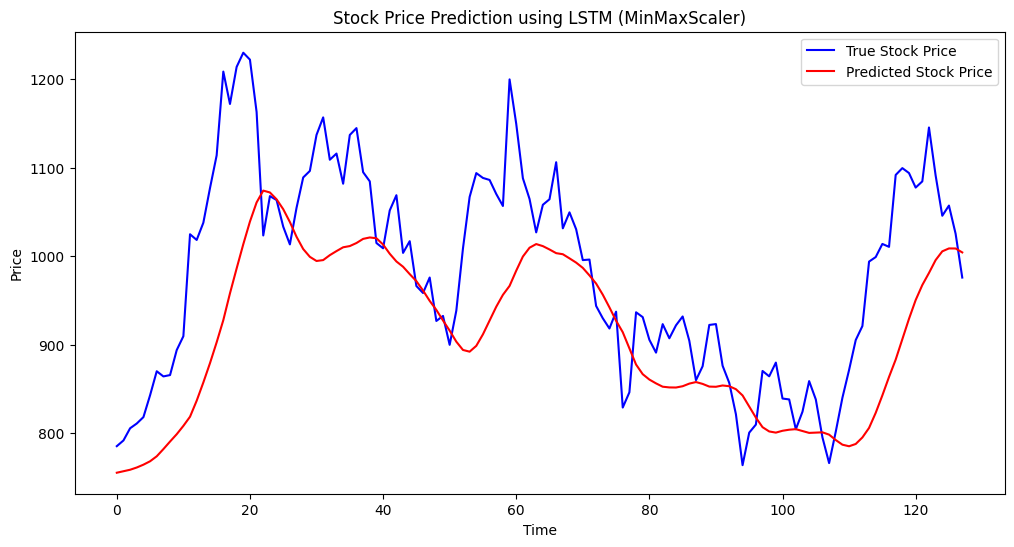

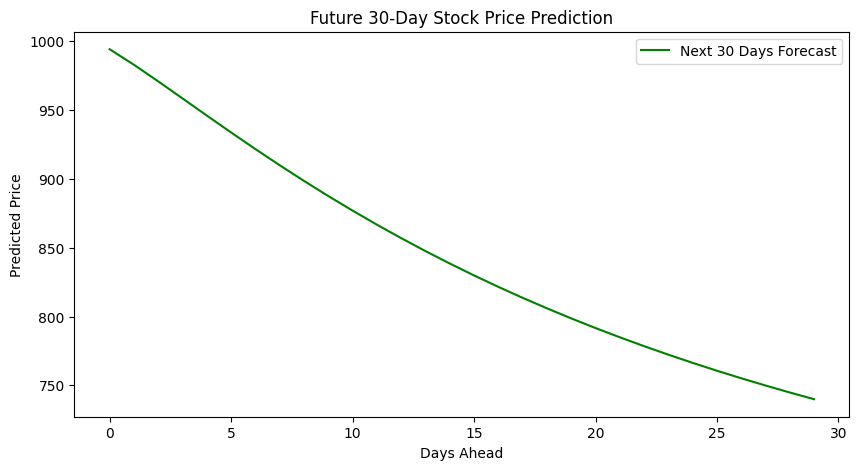

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input

df = pd.read_csv("TSLA.csv")
df = df.sort_values('Date')
data = df[['Close']].values

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

train_size = int(len(scaled_data) * 0.8)
train_data = scaled_data[:train_size]
test_data = scaled_data[train_size - 60:]

def create_dataset(dataset, window=60):
    X, y = [], []
    for i in range(window, len(dataset)):
        X.append(dataset[i-window:i, 0])
        y.append(dataset[i, 0])
    return np.array(X), np.array(y)

window = 60
X_train, y_train = create_dataset(train_data, window)
X_test, y_test = create_dataset(test_data, window)

X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

model = Sequential([
    Input(shape=(X_train.shape[1], 1)),
    LSTM(50, return_sequences=True),
    Dropout(0.2),
    LSTM(50, return_sequences=False),
    Dropout(0.2),
    Dense(25),
    Dense(1)
])

model.compile(optimizer='adam', loss='mean_squared_error')

history = model.fit(X_train, y_train, epochs=25, batch_size=32, verbose=0)

predictions = model.predict(X_test, verbose=0)
predictions = scaler.inverse_transform(predictions)
true_prices = scaler.inverse_transform(y_test.reshape(-1, 1))

mse = mean_squared_error(true_prices, predictions)
print(f"Mean Squared Error (LSTM): {mse:.4f}")

plt.figure(figsize=(12,6))
plt.plot(true_prices, label='True Stock Price', color='blue')
plt.plot(predictions, label='Predicted Stock Price', color='red')
plt.title("Stock Price Prediction using LSTM (MinMaxScaler)")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.show()

last_60 = scaled_data[-60:]
future_input = last_60.reshape(1, 60, 1)
future_predictions = []

for _ in range(30):
    pred = model.predict(future_input, verbose=0)
    future_predictions.append(pred[0, 0])

    future_input = np.append(future_input[:, 1:, :], pred.reshape(1, 1, 1), axis=1)

future_predictions = scaler.inverse_transform(np.array(future_predictions).reshape(-1, 1))

plt.figure(figsize=(10,5))
plt.plot(future_predictions, color='green', label='Next 30 Days Forecast')
plt.title("Future 30-Day Stock Price Prediction")
plt.xlabel("Days Ahead")
plt.ylabel("Predicted Price")
plt.legend()
plt.show()

ARIMA

In [ ]:
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 16.1 MB/s eta 0:00:00


In [ ]:
!pip show pmdarima

Name: pmdarima
Version: 2.1.1
Summary: Python's forecast::auto.arima equivalent
Home-page: http://alkaline-ml.com/pmdarima
Author: 
Author-email: "Taylor G. Smith" <taylor.smith@alkaline-ml.com>
License: 
Location: /usr/local/lib/python3.12/dist-packages
Requires: Cython, joblib, numpy, packaging, pandas, scikit-learn, scipy, setuptools, statsmodels, urllib3
Required-by: 


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


Mean Squared Error (ARIMA on Log Returns): 0.001740


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


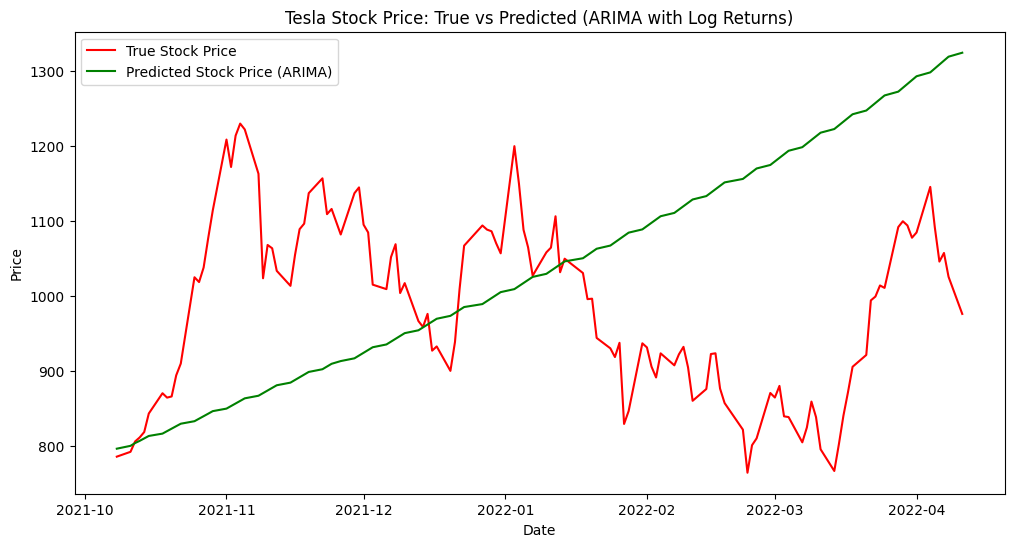

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


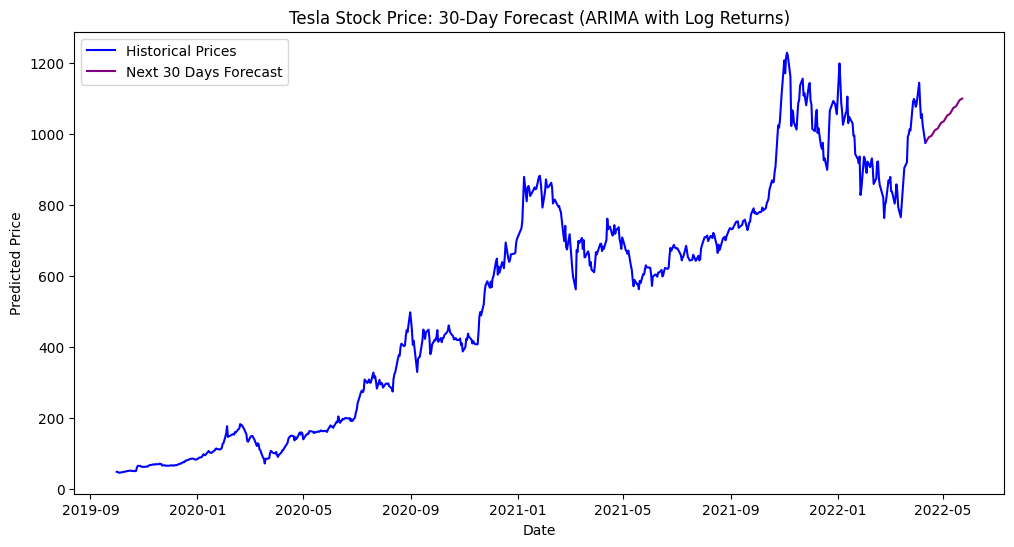

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

df = pd.read_csv("TSLA.csv", parse_dates=['Date'])

df.set_index('Date', inplace=True)

df['Close'] = df['Close'].interpolate()

df['LogReturn'] = np.log(df['Close'] / df['Close'].shift(1))
df.dropna(inplace=True)

train_size = int(len(df) * 0.8)
train_data, test_data = df['LogReturn'][:train_size], df['LogReturn'][train_size:]

order = (5, 1, 2)

model = ARIMA(train_data, order=order)
model_fit = model.fit()

predictions = model_fit.forecast(steps=len(test_data))

mse = mean_squared_error(test_data, predictions)
print(f"Mean Squared Error (ARIMA on Log Returns): {mse:.6f}")

last_train_price = df['Close'].iloc[train_size - 1]
predicted_prices = [last_train_price]

for r in predictions:
    predicted_prices.append(predicted_prices[-1] * np.exp(r))

predicted_prices = predicted_prices[1:]

plt.figure(figsize=(12,6))
plt.plot(df.index[train_size:], df['Close'][train_size:], label='True Stock Price', color='red')
plt.plot(df.index[train_size:], predicted_prices, label='Predicted Stock Price (ARIMA)', color='green')
plt.title("Tesla Stock Price: True vs Predicted (ARIMA with Log Returns)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

future_forecast_returns = model_fit.forecast(steps=30)

last_known_price = df['Close'].iloc[-1]
future_prices = [last_known_price]
for r in future_forecast_returns:
    future_prices.append(future_prices[-1] * np.exp(r))
future_prices = future_prices[1:]

last_date = df.index[-1]
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=30, freq='B')

plt.figure(figsize=(12,6))
plt.plot(df.index, df['Close'], label='Historical Prices', color='blue')
plt.plot(future_dates, future_prices, label='Next 30 Days Forecast', color='purple')
plt.title("Tesla Stock Price: 30-Day Forecast (ARIMA with Log Returns)")
plt.xlabel("Date")
plt.ylabel("Predicted Price")
plt.legend()
plt.show()

RNN USING MINMAX CG

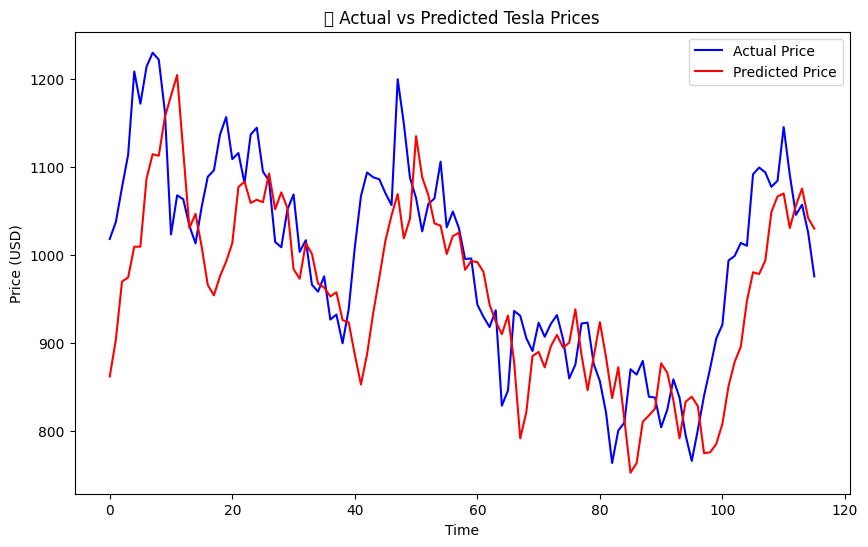

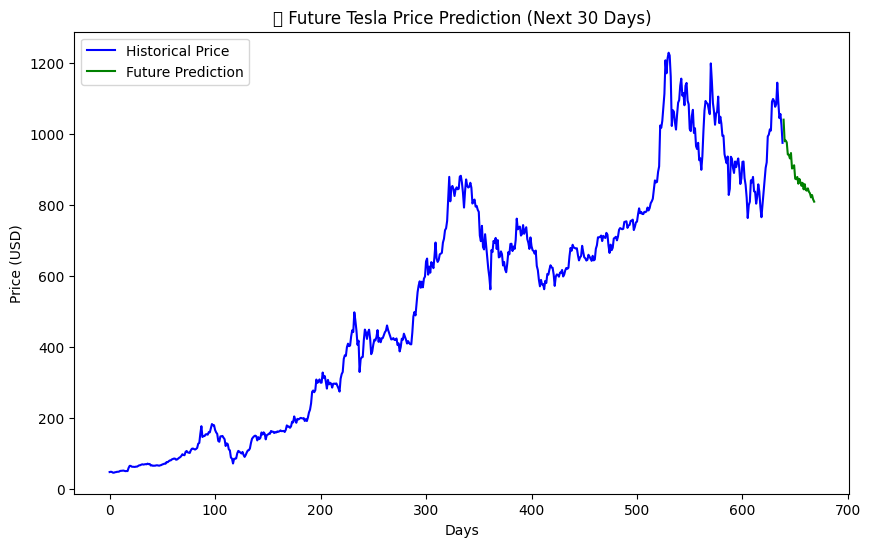

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense
from tensorflow.keras.optimizers import Adam
import tensorflow as tf
import os
import warnings
from sklearn.metrics import mean_squared_error
warnings.filterwarnings("ignore")
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

df = pd.read_csv("TSLA.csv")
data = df[['Close']].values

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

def create_sequences(data, time_steps=60):
    X, y = [], []
    for i in range(time_steps, len(data)):
        X.append(data[i-time_steps:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

time_steps = 60
X, y = create_sequences(scaled_data, time_steps)

split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

model = Sequential([
    SimpleRNN(50, activation='tanh', return_sequences=False, input_shape=(time_steps, 1)),
    Dense(1)
])
model.compile(optimizer=Adam(0.001), loss='mse')

model.fit(X_train, y_train, epochs=30, batch_size=32, validation_data=(X_test, y_test), verbose=0)

predicted = model.predict(X_test, verbose=0)
predicted_prices = scaler.inverse_transform(predicted)
actual_prices = scaler.inverse_transform(y_test.reshape(-1, 1))

mse = mean_squared_error(actual_prices, predicted_prices)
print(f"Mean Squared Error (RNN using MinMax): {mse:.4f}")

plt.figure(figsize=(10,6))
plt.plot(actual_prices, label="Actual Price", color='blue')
plt.plot(predicted_prices, label="Predicted Price", color='red')
plt.title("📈 Actual vs Predicted Tesla Prices")
plt.xlabel("Time")
plt.ylabel("Price (USD)")
plt.legend()
plt.show()

future_steps = 30
last_sequence = scaled_data[-time_steps:]
future_predictions = []

for _ in range(future_steps):
    X_input = last_sequence.reshape((1, time_steps, 1))
    pred = model.predict(X_input, verbose=0)
    future_predictions.append(pred[0, 0])
    last_sequence = np.append(last_sequence[1:], pred[0, 0])

future_predictions = np.array(future_predictions).reshape(-1, 1)
future_prices = scaler.inverse_transform(future_predictions)

plt.figure(figsize=(10,6))
plt.plot(range(len(data)), scaler.inverse_transform(scaled_data), label="Historical Price", color='blue')
plt.plot(range(len(data), len(data)+future_steps), future_prices, label="Future Prediction", color='green')
plt.title("🔮 Future Tesla Price Prediction (Next 30 Days)")
plt.xlabel("Days")
plt.ylabel("Price (USD)")
plt.legend()
plt.show()

RNN using logreturns cg

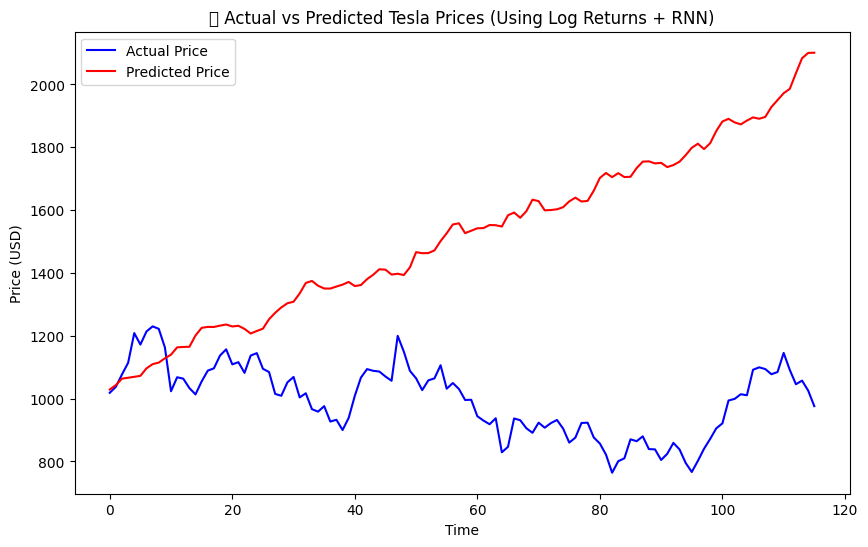

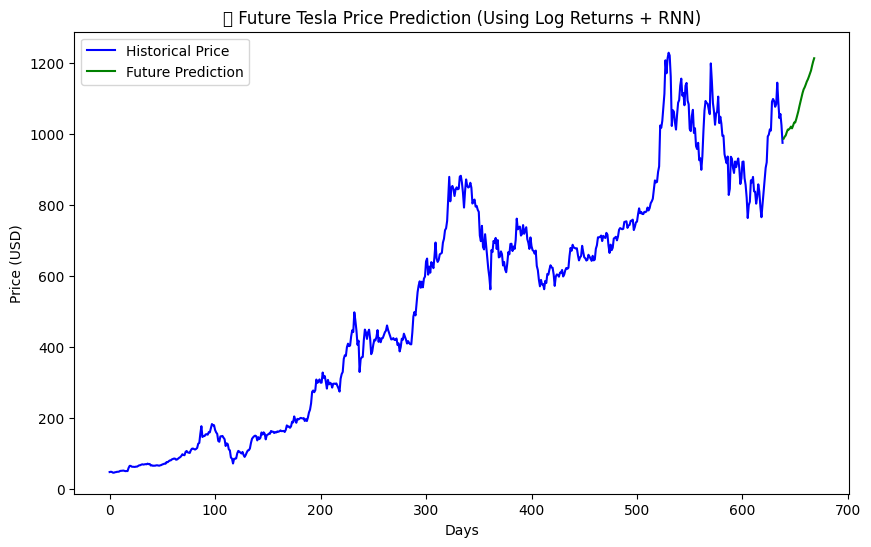

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense
from tensorflow.keras.optimizers import Adam
import tensorflow as tf
import os
import warnings
from sklearn.metrics import mean_squared_error
warnings.filterwarnings("ignore")
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

df = pd.read_csv("TSLA.csv")


prices = df['Close'].values


log_returns = np.log(prices[1:] / prices[:-1])
log_returns = log_returns.reshape(-1, 1)


scaler = MinMaxScaler(feature_range=(0, 1))
scaled_returns = scaler.fit_transform(log_returns)


def create_sequences(data, time_steps=60):
    X, y = [], []
    for i in range(time_steps, len(data)):
        X.append(data[i-time_steps:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

time_steps = 60
X, y = create_sequences(scaled_returns, time_steps)


split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]


X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

model = Sequential([
    SimpleRNN(50, activation='tanh', return_sequences=False, input_shape=(time_steps, 1)),
    Dense(1)
])
model.compile(optimizer=Adam(0.001), loss='mse')


model.fit(X_train, y_train, epochs=30, batch_size=32, validation_data=(X_test, y_test), verbose=0)


predicted_returns = model.predict(X_test, verbose=0)
predicted_returns = scaler.inverse_transform(predicted_returns)
actual_returns = scaler.inverse_transform(y_test.reshape(-1, 1))


start_price = prices[split + time_steps]
predicted_prices = [start_price]

for r in predicted_returns:
    next_price = predicted_prices[-1] * np.exp(r[0])
    predicted_prices.append(next_price)

predicted_prices = np.array(predicted_prices[1:])
actual_prices = prices[split + time_steps + 1 : split + time_steps + 1 + len(predicted_prices)]

mse = mean_squared_error(actual_prices, predicted_prices)
print(f"Mean Squared Error (RNN using Log Returns): {mse:.4f}")


plt.figure(figsize=(10,6))
plt.plot(actual_prices, label="Actual Price", color='blue')
plt.plot(predicted_prices, label="Predicted Price", color='red')
plt.title("📈 Actual vs Predicted Tesla Prices (Using Log Returns + RNN)")
plt.xlabel("Time")
plt.ylabel("Price (USD)")
plt.legend()
plt.show()

future_steps = 30
last_sequence = scaled_returns[-time_steps:]
future_predictions = []

for _ in range(future_steps):
    X_input = last_sequence.reshape((1, time_steps, 1))
    pred = model.predict(X_input, verbose=0)
    future_predictions.append(pred[0, 0])
    last_sequence = np.append(last_sequence[1:], pred[0, 0])


future_predictions = np.array(future_predictions).reshape(-1, 1)
future_log_returns = scaler.inverse_transform(future_predictions)


last_real_price = prices[-1]
future_prices = [last_real_price]
for r in future_log_returns:
    next_price = future_prices[-1] * np.exp(r[0])
    future_prices.append(next_price)
future_prices = np.array(future_prices[1:])

plt.figure(figsize=(10,6))
plt.plot(range(len(prices)), prices, label="Historical Price", color='blue')
plt.plot(range(len(prices), len(prices)+future_steps), future_prices, label="Future Prediction", color='green')
plt.title("🔮 Future Tesla Price Prediction (Using Log Returns + RNN)")
plt.xlabel("Days")
plt.ylabel("Price (USD)")
plt.legend()
plt.show()

RNN using minmax+logreturns

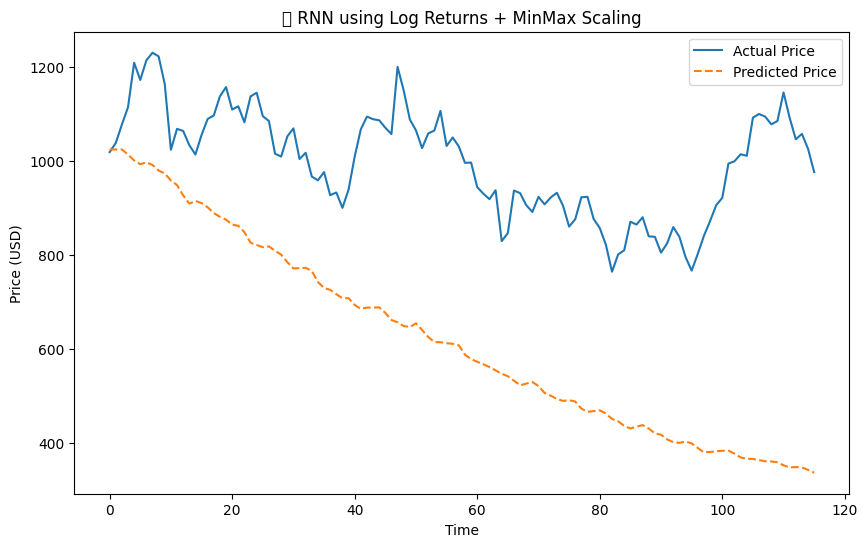

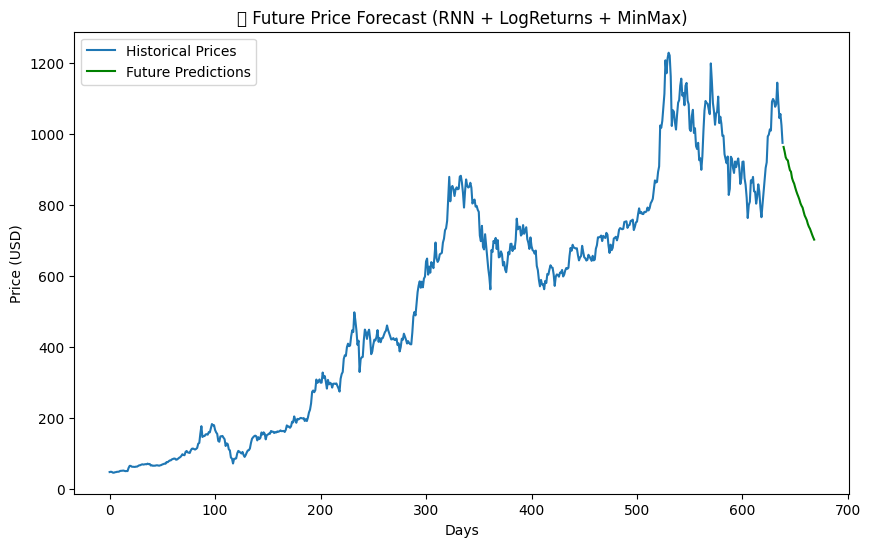

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense
from tensorflow.keras.optimizers import Adam
import warnings, os
from sklearn.metrics import mean_squared_error
warnings.filterwarnings("ignore")
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

df = pd.read_csv("TSLA.csv")
prices = df['Close'].values.reshape(-1, 1)


log_returns = np.log(prices[1:] / prices[:-1])


scaler = MinMaxScaler(feature_range=(0, 1))
scaled = scaler.fit_transform(log_returns)


def create_sequences(data, time_steps=60):
    X, y = [], []
    for i in range(time_steps, len(data)):
        X.append(data[i - time_steps:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X, y = create_sequences(scaled)
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))


model = Sequential([
    SimpleRNN(50, activation='tanh', input_shape=(X_train.shape[1], 1)),
    Dense(1)
])
model.compile(optimizer=Adam(0.001), loss='mse')

model.fit(X_train, y_train, epochs=30, batch_size=32,
          validation_data=(X_test, y_test), verbose=0)


pred_scaled = model.predict(X_test, verbose=0)


pred_logret = scaler.inverse_transform(pred_scaled)
true_logret = scaler.inverse_transform(y_test.reshape(-1, 1))

start_price = prices[split + 60]
pred_prices = [start_price]
for r in pred_logret:
    pred_prices.append(pred_prices[-1] * np.exp(r[0]))
pred_prices = np.array(pred_prices[1:])
actual_prices = prices[split + 61: split + 61 + len(pred_prices)]


mse = mean_squared_error(actual_prices, pred_prices)
print(f"Mean Squared Error (RNN using Log Returns + MinMax): {mse:.4f}")


plt.figure(figsize=(10,6))
plt.plot(actual_prices, label="Actual Price")
plt.plot(pred_prices, label="Predicted Price", linestyle='--')
plt.title("📈 RNN using Log Returns + MinMax Scaling")
plt.xlabel("Time")
plt.ylabel("Price (USD)")
plt.legend()
plt.show()


future_steps = 30
last_seq = scaled[-60:]
future_preds = []

for _ in range(future_steps):
    X_input = last_seq.reshape(1, 60, 1)
    pred = model.predict(X_input, verbose=0)[0, 0]
    future_preds.append(pred)
    last_seq = np.append(last_seq[1:], pred)

future_preds = np.array(future_preds).reshape(-1, 1)
future_logreturns = scaler.inverse_transform(future_preds)


last_known_price = prices[-1]
future_prices = [last_known_price]
for r in future_logreturns:
    future_prices.append(future_prices[-1] * np.exp(r[0]))
future_prices = np.array(future_prices[1:])

plt.figure(figsize=(10,6))
plt.plot(range(len(prices)), prices, label="Historical Prices")
plt.plot(range(len(prices), len(prices) + len(future_prices)),
         future_prices, label="Future Predictions", color='green')
plt.title("🔮 Future Price Forecast (RNN + LogReturns + MinMax)")
plt.xlabel("Days")
plt.ylabel("Price (USD)")
plt.legend()
plt.show()

LNN using minmax

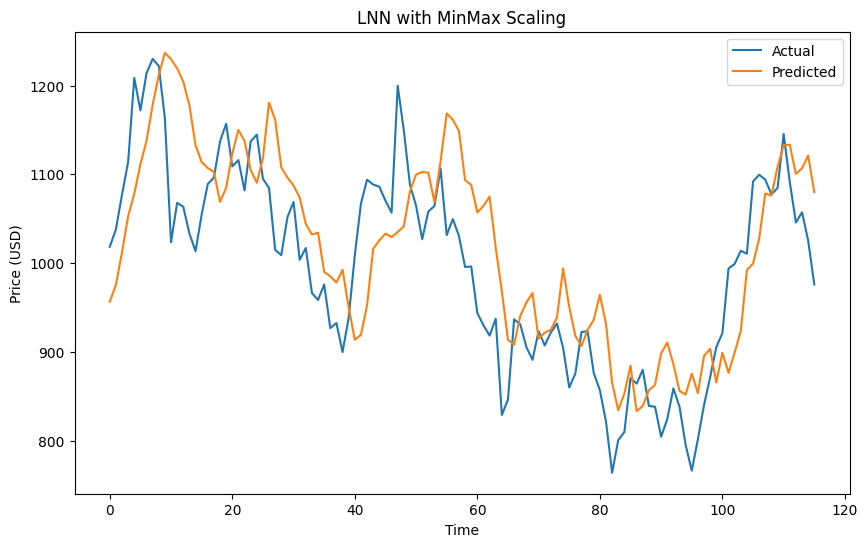

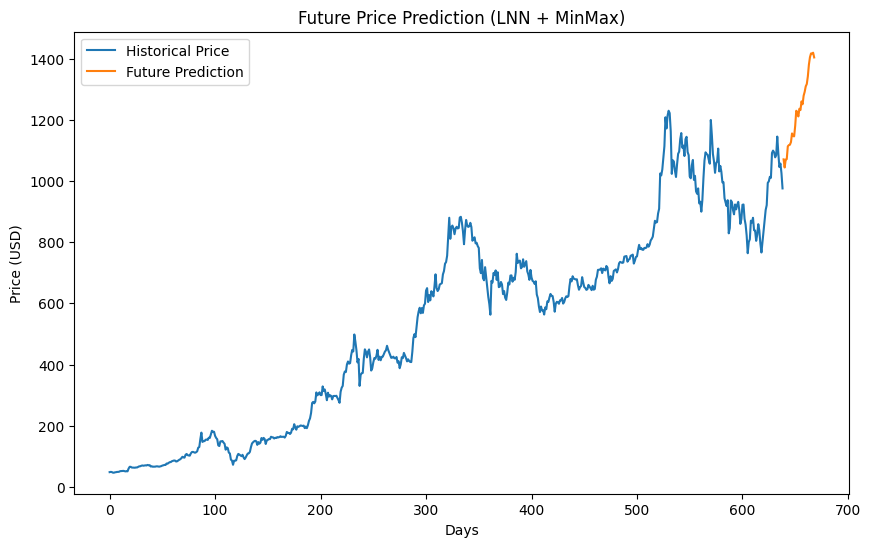

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error

df = pd.read_csv("TSLA.csv")
prices = df['Close'].values.reshape(-1, 1)


scaler = MinMaxScaler(feature_range=(0, 1))
scaled = scaler.fit_transform(prices)


def create_sequences(data, time_steps=60):
    X, y = [], []
    for i in range(time_steps, len(data)):
        X.append(data[i-time_steps:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X, y = create_sequences(scaled)
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y[:split], y[split:]


model = Sequential([
    Flatten(input_shape=(60,)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1)
])
model.compile(optimizer=Adam(0.001), loss='mse')
model.fit(X_train, y_train, epochs=25, batch_size=32, verbose=0)


pred = model.predict(X_test, verbose=0)
predicted_prices = scaler.inverse_transform(pred)
actual_prices = scaler.inverse_transform(y_test.reshape(-1, 1))


mse = mean_squared_error(actual_prices, predicted_prices)
print(f"Mean Squared Error (LNN with MinMax): {mse:.4f}")


plt.figure(figsize=(10,6))
plt.plot(actual_prices, label="Actual")
plt.plot(predicted_prices, label="Predicted")
plt.title("LNN with MinMax Scaling")
plt.xlabel("Time")
plt.ylabel("Price (USD)")
plt.legend()
plt.show()


future_steps = 30
last_seq = scaled[-60:]
future_preds = []
for _ in range(future_steps):
    pred = model.predict(last_seq.reshape(1, 60), verbose=0)[0, 0]
    future_preds.append(pred)
    last_seq = np.append(last_seq[1:], pred)
future_prices = scaler.inverse_transform(np.array(future_preds).reshape(-1, 1))

plt.figure(figsize=(10,6))
plt.plot(range(len(prices)), prices, label="Historical Price")
plt.plot(range(len(prices), len(prices)+future_steps), future_prices, label="Future Prediction")
plt.title("Future Price Prediction (LNN + MinMax)")
plt.xlabel("Days")
plt.ylabel("Price (USD)")
plt.legend()
plt.show()

LNN using logreturns

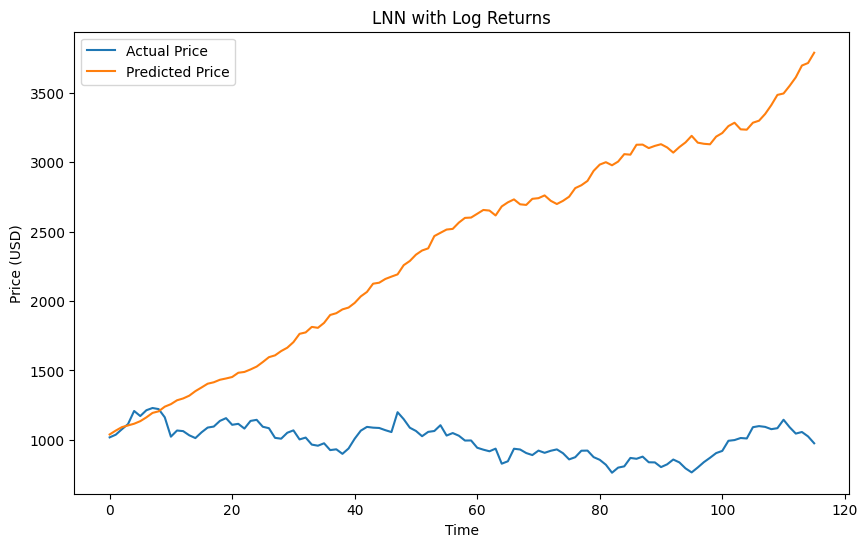

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error

df = pd.read_csv("TSLA.csv")
prices = df['Close'].values.reshape(-1, 1)


log_returns = np.log(prices[1:] / prices[:-1])


scaler = MinMaxScaler(feature_range=(0, 1))
scaled = scaler.fit_transform(log_returns)

def create_sequences(data, time_steps=60):
    X, y = [], []
    for i in range(time_steps, len(data)):
        X.append(data[i-time_steps:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X, y = create_sequences(scaled)
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]


model = Sequential([
    Flatten(input_shape=(60,)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1)
])
model.compile(optimizer=Adam(0.001), loss='mse')
model.fit(X_train, y_train, epochs=25, batch_size=32, verbose=0)


pred = model.predict(X_test, verbose=0)
pred_log_returns = scaler.inverse_transform(pred)
y_test_log_returns = scaler.inverse_transform(y_test.reshape(-1,1))


start_price = prices[split + 60]
pred_prices = [start_price]
for r in pred_log_returns:
    pred_prices.append(pred_prices[-1] * np.exp(r[0]))
pred_prices = np.array(pred_prices[1:])
actual_prices = prices[split + 61: split + 61 + len(pred_prices)]


mse = mean_squared_error(actual_prices, pred_prices)
print(f"Mean Squared Error (LNN with Log Returns): {mse:.4f}")


plt.figure(figsize=(10,6))
plt.plot(actual_prices, label="Actual Price")
plt.plot(pred_prices, label="Predicted Price")
plt.title("LNN with Log Returns")
plt.xlabel("Time")
plt.ylabel("Price (USD)")
plt.legend()
plt.show()

LNN using minmax+logreturns


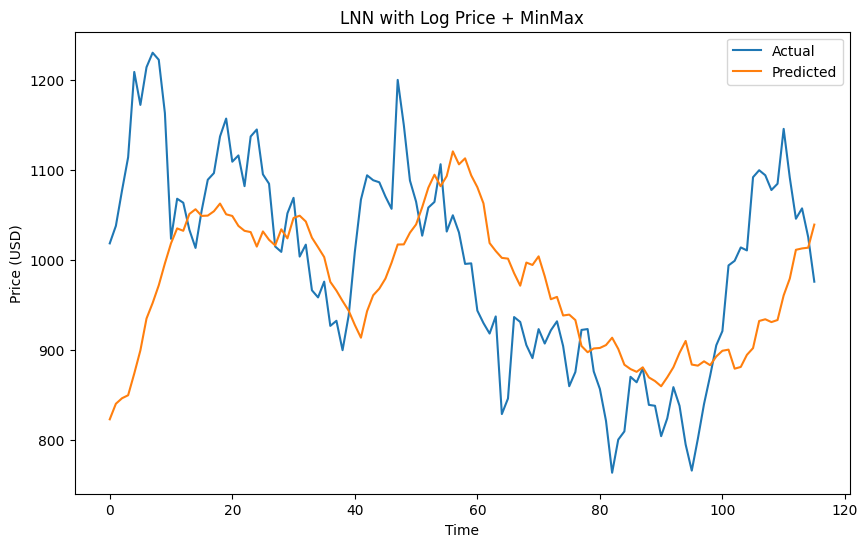

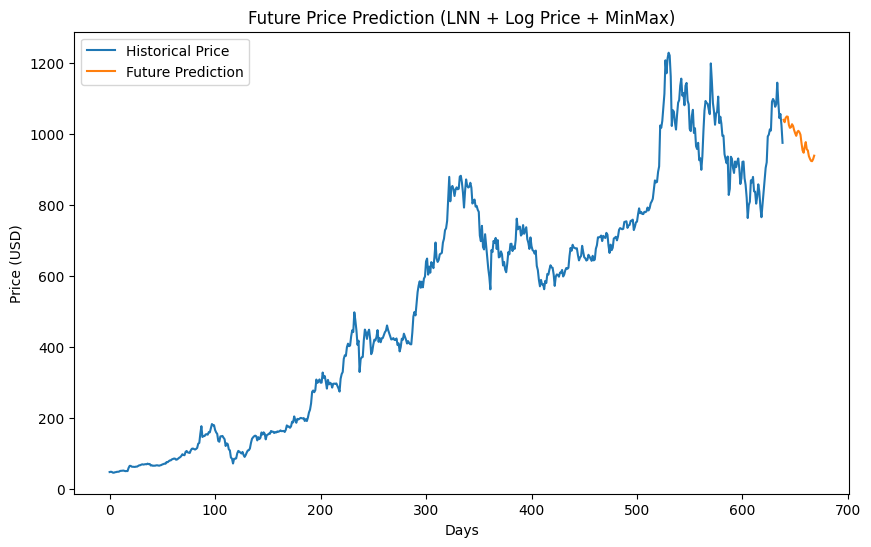

In [ ]:
# ============================
# 📘 LNN using Log Price + MinMax
# ============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error

# Load dataset
df = pd.read_csv("TSLA.csv")
prices = df['Close'].values.reshape(-1, 1)

# Log transform
log_prices = np.log(prices)

# Scale
scaler = MinMaxScaler(feature_range=(0, 1))
scaled = scaler.fit_transform(log_prices)

# Create sequences
def create_sequences(data, time_steps=60):
    X, y = [], []
    for i in range(time_steps, len(data)):
        X.append(data[i-time_steps:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X, y = create_sequences(scaled)
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# LNN Model
model = Sequential([
    Flatten(input_shape=(60,)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1)
])
model.compile(optimizer=Adam(0.001), loss='mse')
model.fit(X_train, y_train, epochs=25, batch_size=32, verbose=0)

# Predict and inverse transform
pred = model.predict(X_test, verbose=0)
pred_scaled_log_prices = scaler.inverse_transform(pred)
y_test_scaled_log_prices = scaler.inverse_transform(y_test.reshape(-1,1))

# Convert back from log
pred_prices = np.exp(pred_scaled_log_prices)
actual_prices = np.exp(y_test_scaled_log_prices)

# Calculate MSE
mse = mean_squared_error(actual_prices, pred_prices)
print(f"Mean Squared Error (LNN with Log Price + MinMax): {mse:.4f}")

# Plot Actual vs Predicted
plt.figure(figsize=(10,6))
plt.plot(actual_prices, label="Actual")
plt.plot(pred_prices, label="Predicted")
plt.title("LNN with Log Price + MinMax")
plt.xlabel("Time")
plt.ylabel("Price (USD)")
plt.legend()
plt.show()

# Future Prediction
future_steps = 30
last_seq = scaled[-60:]
future_preds = []
for _ in range(future_steps):
    pred = model.predict(last_seq.reshape(1, 60), verbose=0)[0, 0]
    future_preds.append(pred)
    last_seq = np.append(last_seq[1:], pred)
future_prices = np.exp(scaler.inverse_transform(np.array(future_preds).reshape(-1, 1)))

plt.figure(figsize=(10,6))
plt.plot(range(len(prices)), prices, label="Historical Price")
plt.plot(range(len(prices), len(prices)+future_steps), future_prices, label="Future Prediction")
plt.title("Future Price Prediction (LNN + Log Price + MinMax)")
plt.xlabel("Days")
plt.ylabel("Price (USD)")
plt.legend()
plt.show()

#GARCH MODEL

In [ ]:
!pip install arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 50.1 MB/s eta 0:00:00


In [ ]:
from google.colab import files
uploaded = files.upload()


Saving TSLA.csv to TSLA (1).csv


Mean Squared Error (GARCH): 141537.5938


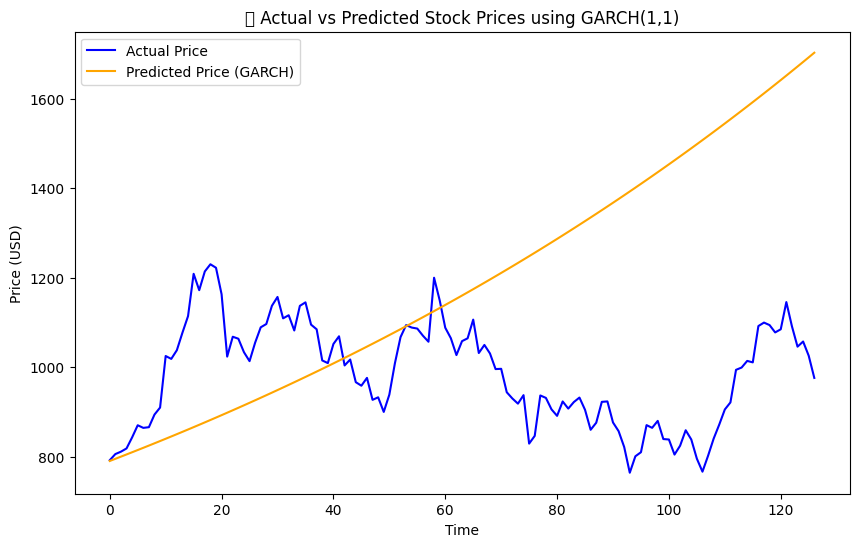

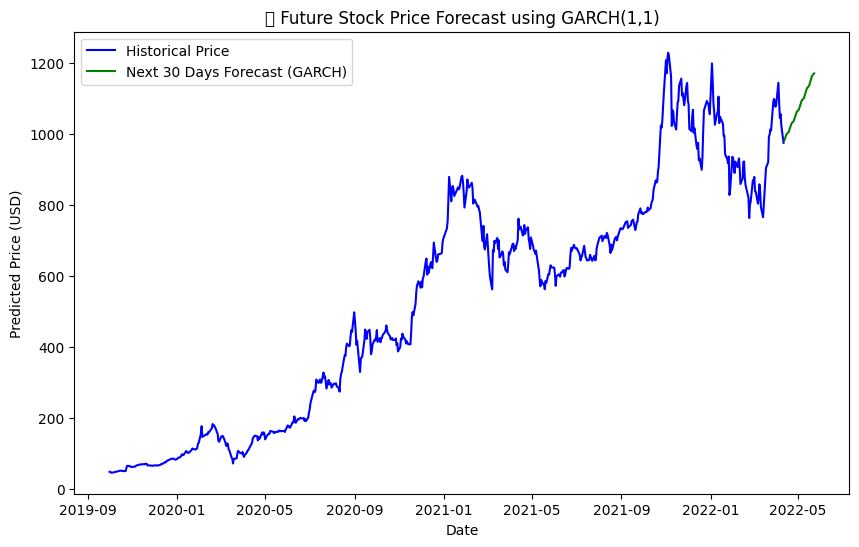

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from arch import arch_model
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("TSLA.csv", parse_dates=['Date'])
df = df.sort_values('Date')

df['LogReturn'] = np.log(df['Close'] / df['Close'].shift(1))
df.dropna(inplace=True)

train_size = int(len(df) * 0.8)
train, test = df['LogReturn'][:train_size], df['LogReturn'][train_size:]

model = arch_model(train, vol='Garch', p=1, q=1, mean='Constant', dist='normal')
model_fit = model.fit(disp='off')

forecast = model_fit.forecast(horizon=len(test))
predicted_returns = forecast.mean.values[-1]

last_train_price = df['Close'].iloc[train_size]
predicted_prices = [last_train_price]
for r in predicted_returns:
    predicted_prices.append(predicted_prices[-1] * np.exp(r))
predicted_prices = predicted_prices[1:]

true_prices = df['Close'].iloc[train_size+1 : train_size+1+len(predicted_prices)]

min_len = min(len(true_prices), len(predicted_prices))
true_prices = true_prices[:min_len]
predicted_prices = predicted_prices[:min_len]

mse = mean_squared_error(true_prices, predicted_prices)
print(f"Mean Squared Error (GARCH): {mse:.4f}")

plt.figure(figsize=(10,6))
plt.plot(true_prices.values, label="Actual Price", color='blue')
plt.plot(predicted_prices, label="Predicted Price (GARCH)", color='orange')
plt.title("📈 Actual vs Predicted Stock Prices using GARCH(1,1)")
plt.xlabel("Time")
plt.ylabel("Price (USD)")
plt.legend()
plt.show()

future_forecast = model_fit.forecast(horizon=30)
future_returns = future_forecast.mean.values[-1]

last_known_price = df['Close'].iloc[-1]
future_prices = [last_known_price]
for r in future_returns:
    future_prices.append(future_prices[-1] * np.exp(r))
future_prices = np.array(future_prices[1:])

future_dates = pd.date_range(start=df['Date'].iloc[-1] + pd.Timedelta(days=1), periods=30, freq='B')

plt.figure(figsize=(10,6))
plt.plot(df['Date'], df['Close'], label="Historical Price", color='blue')
plt.plot(future_dates, future_prices, label="Next 30 Days Forecast (GARCH)", color='green')
plt.title("🔮 Future Stock Price Forecast using GARCH(1,1)")
plt.xlabel("Date")
plt.ylabel("Predicted Price (USD)")
plt.legend()
plt.show()

#GRU MODEL

Mean Squared Error (GRU): 5648.5322


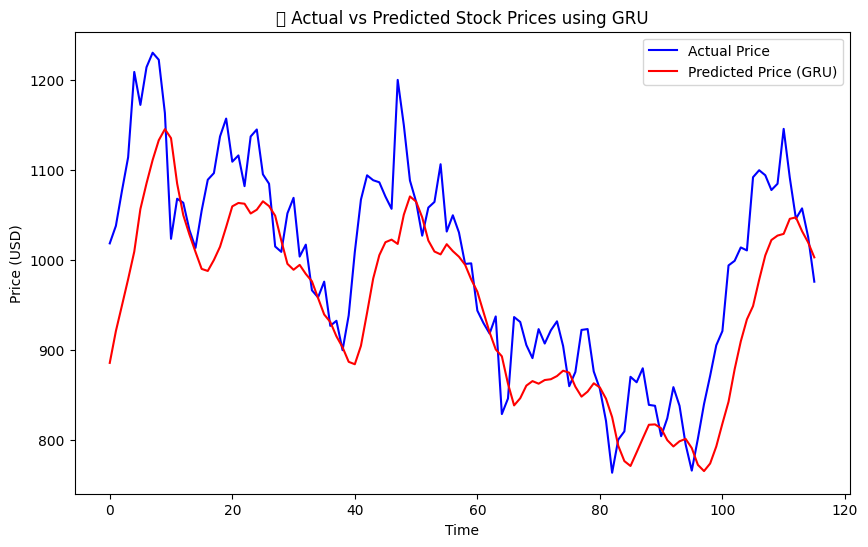

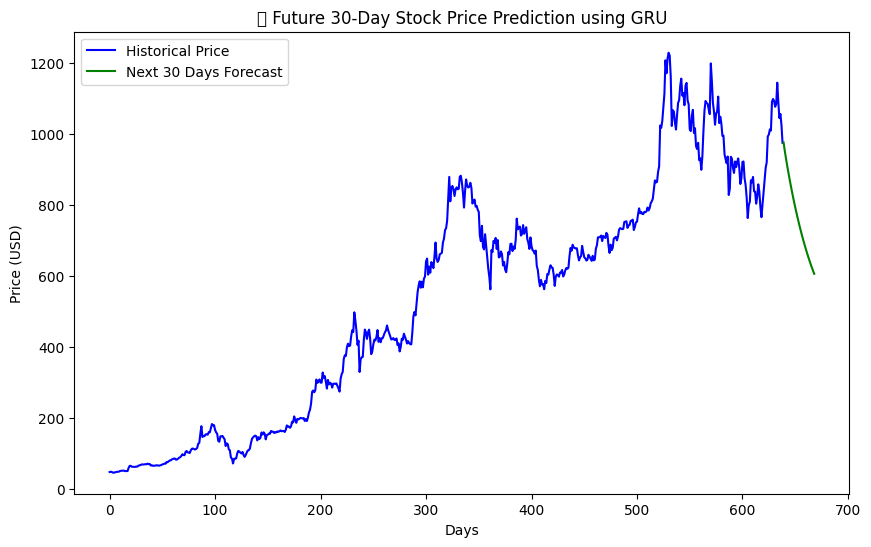

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
import warnings, os
warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

df = pd.read_csv("TSLA.csv")
df = df.sort_values("Date")
data = df[["Close"]].values

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

def create_sequences(dataset, window=60):
    X, y = [], []
    for i in range(window, len(dataset)):
        X.append(dataset[i-window:i, 0])
        y.append(dataset[i, 0])
    return np.array(X), np.array(y)

window = 60
X, y = create_sequences(scaled_data, window)

split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test  = X_test.reshape((X_test.shape[0],  X_test.shape[1],  1))

model = Sequential([
    GRU(64, return_sequences=True, input_shape=(window, 1)),
    Dropout(0.2),
    GRU(64, return_sequences=False),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(1)
])

model.compile(optimizer="adam", loss="mean_squared_error")

history = model.fit(X_train, y_train, epochs=30, batch_size=32,
                    validation_data=(X_test, y_test), verbose=0)

predicted_scaled = model.predict(X_test, verbose=0)
predicted_prices = scaler.inverse_transform(predicted_scaled)
actual_prices = scaler.inverse_transform(y_test.reshape(-1, 1))

mse = mean_squared_error(actual_prices, predicted_prices)
print(f"Mean Squared Error (GRU): {mse:.4f}")

plt.figure(figsize=(10,6))
plt.plot(actual_prices, label="Actual Price", color="blue")
plt.plot(predicted_prices, label="Predicted Price (GRU)", color="red")
plt.title("📈 Actual vs Predicted Stock Prices using GRU")
plt.xlabel("Time")
plt.ylabel("Price (USD)")
plt.legend()
plt.show()

future_steps = 30
last_seq = scaled_data[-window:]
future_predictions = []

for _ in range(future_steps):
    X_input = last_seq.reshape((1, window, 1))
    pred = model.predict(X_input, verbose=0)
    future_predictions.append(pred[0, 0])
    last_seq = np.append(last_seq[1:], pred[0, 0])

future_predictions = np.array(future_predictions).reshape(-1, 1)
future_prices = scaler.inverse_transform(future_predictions)

plt.figure(figsize=(10,6))
plt.plot(range(len(data)), scaler.inverse_transform(scaled_data),
         label="Historical Price", color="blue")
plt.plot(range(len(data), len(data)+future_steps), future_prices,
         label="Next 30 Days Forecast", color="green")
plt.title("🔮 Future 30-Day Stock Price Prediction using GRU")
plt.xlabel("Days")
plt.ylabel("Price (USD)")
plt.legend()
plt.show()

## Hybrid RNN+GRU Model Implementation (All Steps in One Cell)

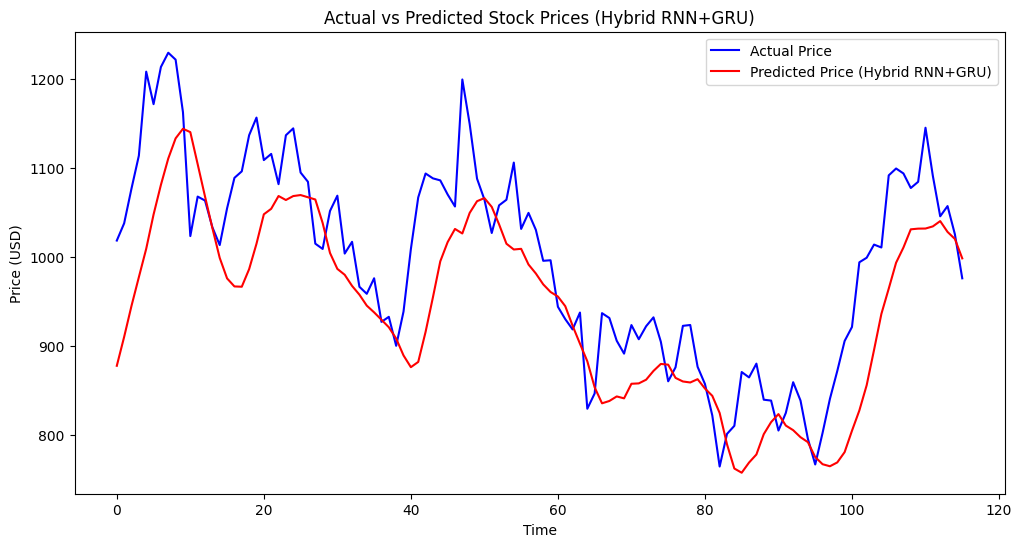

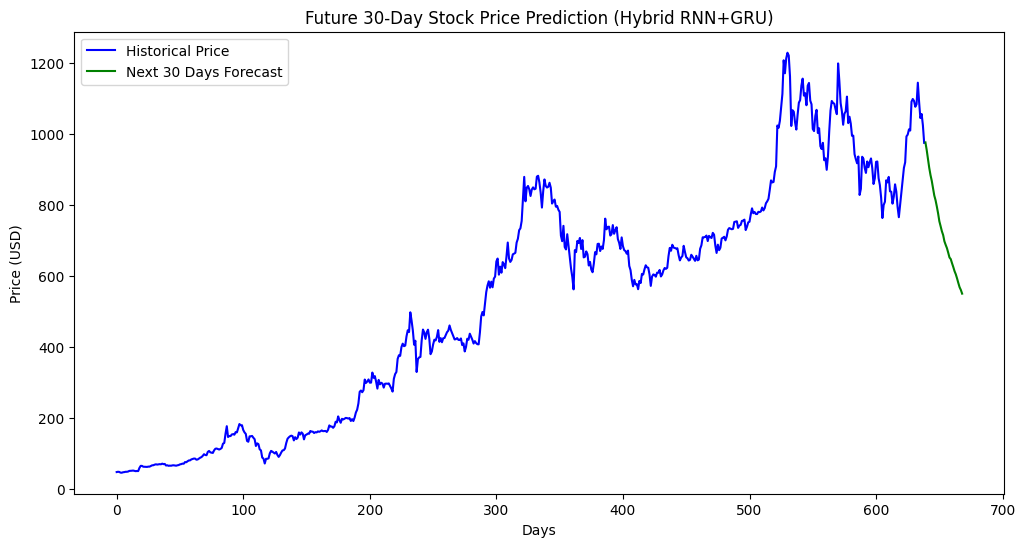

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, GRU, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error
import warnings, os
warnings.filterwarnings("ignore")
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

df = pd.read_csv("TSLA.csv")
data = df[['Close']].values

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

def create_sequences(data, time_steps=60):
    X, y = [], []
    for i in range(time_steps, len(data)):
        X.append(data[i-time_steps:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

time_steps = 60
X, y = create_sequences(scaled_data, time_steps)

split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

model = Sequential([
    SimpleRNN(64, return_sequences=True, input_shape=(time_steps, 1)),
    Dropout(0.2),
    GRU(64, return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

model.compile(optimizer=Adam(0.001), loss='mean_squared_error')

history = model.fit(X_train, y_train, epochs=30, batch_size=32, validation_data=(X_test, y_test), verbose=0)

predicted_scaled = model.predict(X_test, verbose=0)
predicted_prices = scaler.inverse_transform(predicted_scaled)
actual_prices = scaler.inverse_transform(y_test.reshape(-1, 1))

mse = mean_squared_error(actual_prices, predicted_prices)
print(f"Mean Squared Error (Hybrid RNN+GRU): {mse:.4f}")

plt.figure(figsize=(12, 6))
plt.plot(actual_prices, label='Actual Price', color='blue')
plt.plot(predicted_prices, label='Predicted Price (Hybrid RNN+GRU)', color='red')
plt.title('Actual vs Predicted Stock Prices (Hybrid RNN+GRU)')
plt.xlabel('Time')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()

future_steps = 30
last_sequence = scaled_data[-time_steps:]
future_predictions = []

for _ in range(future_steps):
    X_input = last_sequence.reshape((1, time_steps, 1))
    pred = model.predict(X_input, verbose=0)[0, 0]
    future_predictions.append(pred)
    last_sequence = np.append(last_sequence[1:], pred)

future_predictions = np.array(future_predictions).reshape(-1, 1)
future_prices = scaler.inverse_transform(future_predictions)

plt.figure(figsize=(12, 6))
plt.plot(range(len(data)), scaler.inverse_transform(scaled_data), label='Historical Price', color='blue')
plt.plot(range(len(data), len(data) + future_steps), future_prices, label='Next 30 Days Forecast', color='green')
plt.title('Future 30-Day Stock Price Prediction (Hybrid RNN+GRU)')
plt.xlabel('Days')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving TSLA.csv to TSLA.csv


LNN + GRU

## LNN + GRU Hybrid Model Plots

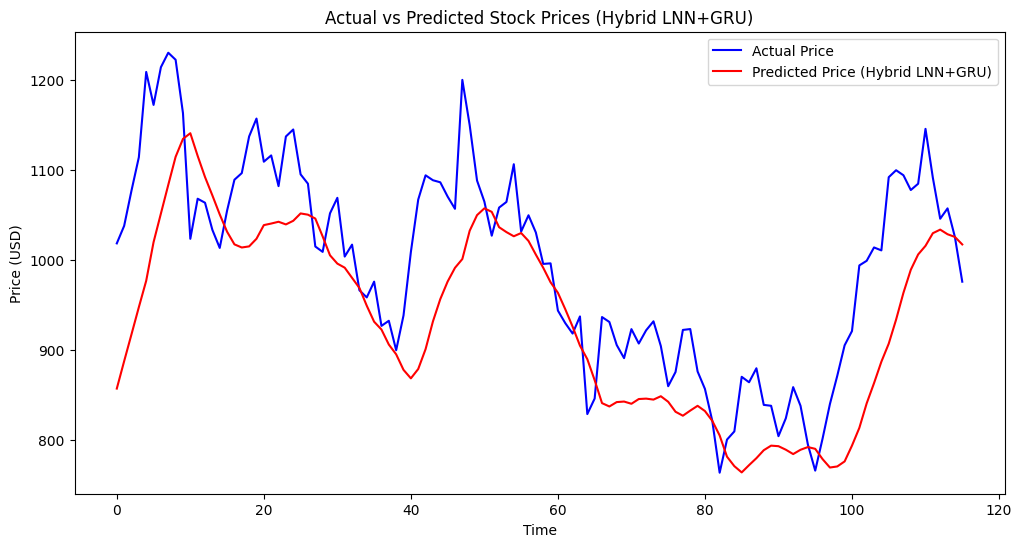

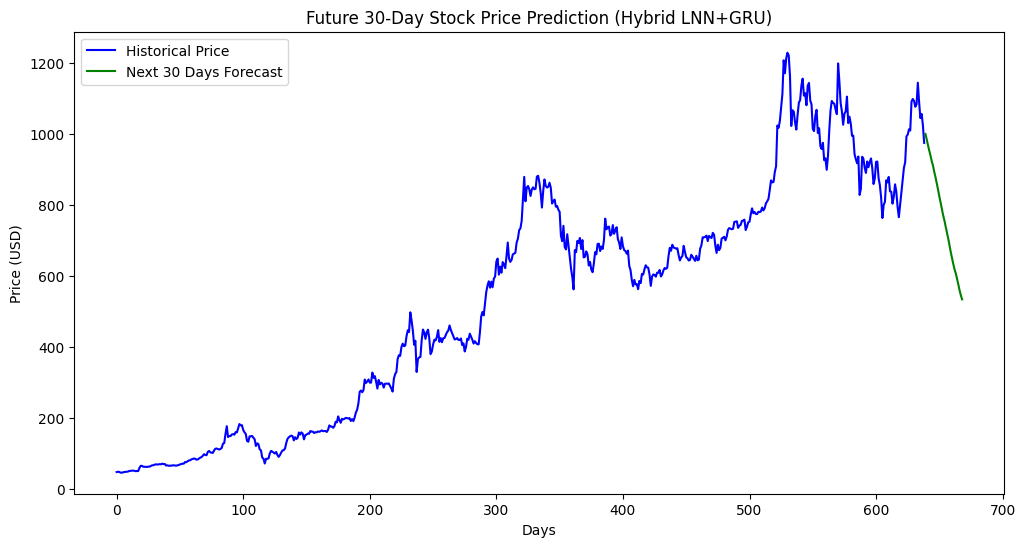

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout, Flatten
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error
import warnings, os
warnings.filterwarnings("ignore")
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

df = pd.read_csv("TSLA.csv")
data = df[['Close']].values

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

def create_sequences(data, time_steps=60):
    X, y = [], []
    for i in range(time_steps, len(data)):
        X.append(data[i-time_steps:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

time_steps = 60
X, y = create_sequences(scaled_data, time_steps)

split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

model = Sequential([
    GRU(64, return_sequences=True, input_shape=(time_steps, 1)),
    Dropout(0.2),
    Flatten(),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1)
])

model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')

history = model.fit(X_train, y_train, epochs=30, batch_size=32, validation_data=(X_test, y_test), verbose=0)

predicted_scaled = model.predict(X_test, verbose=0)
predicted_prices = scaler.inverse_transform(predicted_scaled)
actual_prices = scaler.inverse_transform(y_test.reshape(-1, 1))

mse = mean_squared_error(actual_prices, predicted_prices)
print(f"Mean Squared Error (Hybrid LNN+GRU): {mse:.4f}")

plt.figure(figsize=(12, 6))
plt.plot(actual_prices, label='Actual Price', color='blue')
plt.plot(predicted_prices, label='Predicted Price (Hybrid LNN+GRU)', color='red')
plt.title('Actual vs Predicted Stock Prices (Hybrid LNN+GRU)')
plt.xlabel('Time')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()

future_steps = 30
last_sequence = scaled_data[-time_steps:]
future_predictions = []

for _ in range(future_steps):
    X_input = last_sequence.reshape((1, time_steps, 1))
    pred = model.predict(X_input, verbose=0)[0, 0]
    future_predictions.append(pred)
    last_sequence = np.append(last_sequence[1:], pred)

future_predictions = np.array(future_predictions).reshape(-1, 1)
future_prices = scaler.inverse_transform(future_predictions)

plt.figure(figsize=(12, 6))
plt.plot(range(len(data)), scaler.inverse_transform(scaled_data), label='Historical Price', color='blue')
plt.plot(range(len(data), len(data) + future_steps), future_prices, label='Next 30 Days Forecast', color='green')
plt.title('Future 30-Day Stock Price Prediction (Hybrid LNN+GRU)')
plt.xlabel('Days')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()

## RNN + LNN Hybrid Model Plots

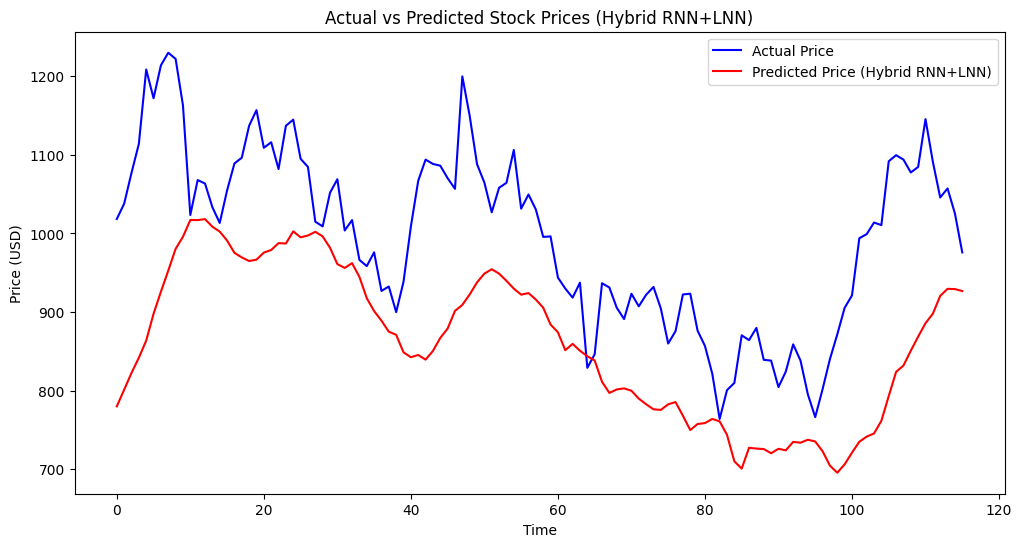

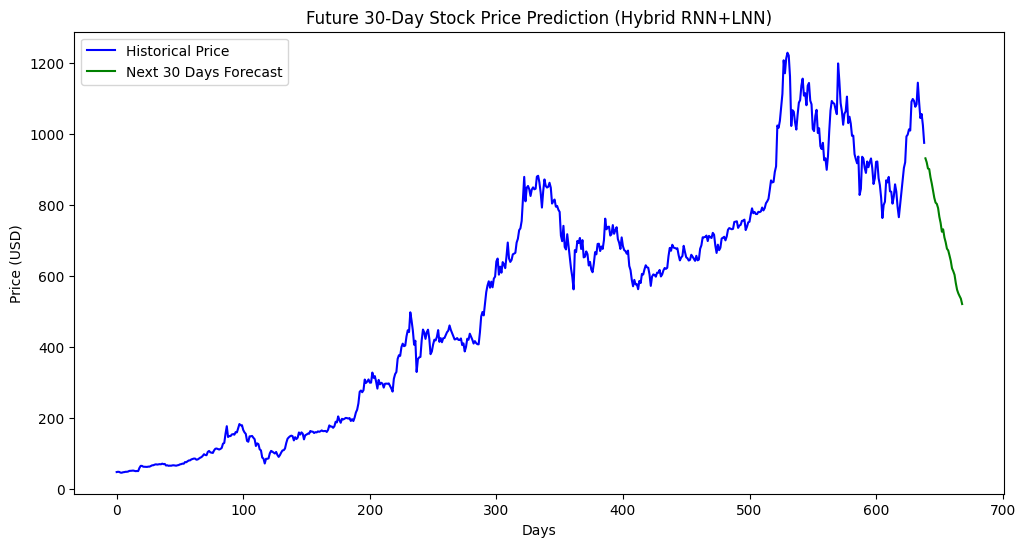

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout, Flatten
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error
import warnings, os
warnings.filterwarnings("ignore")
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

df = pd.read_csv("TSLA.csv")
data = df[['Close']].values

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

def create_sequences(data, time_steps=60):
    X, y = [], []
    for i in range(time_steps, len(data)):
        X.append(data[i-time_steps:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

time_steps = 60
X, y = create_sequences(scaled_data, time_steps)

split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

model = Sequential([
    SimpleRNN(64, return_sequences=True, input_shape=(time_steps, 1)),
    Dropout(0.2),
    Flatten(),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1)
])

model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')

history = model.fit(X_train, y_train, epochs=30, batch_size=32, validation_data=(X_test, y_test), verbose=0)

predicted_scaled = model.predict(X_test, verbose=0)
predicted_prices = scaler.inverse_transform(predicted_scaled)
actual_prices = scaler.inverse_transform(y_test.reshape(-1, 1))

mse = mean_squared_error(actual_prices, predicted_prices)
print(f"Mean Squared Error (Hybrid RNN+LNN): {mse:.4f}")

plt.figure(figsize=(12, 6))
plt.plot(actual_prices, label='Actual Price', color='blue')
plt.plot(predicted_prices, label='Predicted Price (Hybrid RNN+LNN)', color='red')
plt.title('Actual vs Predicted Stock Prices (Hybrid RNN+LNN)')
plt.xlabel('Time')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()

future_steps = 30
last_sequence = scaled_data[-time_steps:]
future_predictions = []

for _ in range(future_steps):
    X_input = last_sequence.reshape((1, time_steps, 1))
    pred = model.predict(X_input, verbose=0)[0, 0]
    future_predictions.append(pred)
    last_sequence = np.append(last_sequence[1:], pred)

future_predictions = np.array(future_predictions).reshape(-1, 1)
future_prices = scaler.inverse_transform(future_predictions)

plt.figure(figsize=(12, 6))
plt.plot(range(len(data)), scaler.inverse_transform(scaled_data), label='Historical Price', color='blue')
plt.plot(range(len(data), len(data) + future_steps), future_prices, label='Next 30 Days Forecast', color='green')
plt.title('Future 30-Day Stock Price Prediction (Hybrid RNN+LNN)')
plt.xlabel('Days')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()